# SIMILIS Baseline — итоговый отчёт

Воспроизводимый сводный ноутбук по треку **1.1 SIMILIS — baseline**. Здесь нет обучения и нет вычислений на GPU — все
цифры, графики и confusion matrices читаются из уже сохранённых артефактов pipeline.

Pipeline-скрипты: `src/similis_baseline/data_prep.py`, `train.py`, `evaluate_detailed.py`, `predict.py`,
`data_report.py`, `error_factor_report.py`, `ablation_report.py`, `cautious_examples.py`, `safe_crop_demo.py`,
`one_batch_debug.py`, `tiny_overfit.py`.

Подробное обоснование решений — в `REPORT.md`. Подробный gap-чеклист — в `IMPLEMENTATION_CHECKLIST.md`.


## 1. Окружение, seed и рабочие папки

In [1]:
import json, sys, platform, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torchvision
from IPython.display import Image as IPyImage, Markdown, display

ROOT = Path('.').resolve()
print('cwd          :', ROOT)
print('python       :', sys.version.split()[0])
print('platform     :', platform.platform())
print('torch        :', torch.__version__)
print('torchvision  :', torchvision.__version__)
print('cuda         :', torch.cuda.is_available())
print('mps          :', getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available())


cwd          : /Users/gipnotyin/Downloads/similis_baseline_project
python       : 3.13.0
platform     : macOS-26.1-arm64-arm-64bit-Mach-O
torch        : 2.11.0
torchvision  : 0.26.0
cuda         : False
mps          : True


In [2]:
for p in [
    'data/raw', 'data/processed', 'splits',
    'artifacts/checkpoints', 'artifacts/preds', 'artifacts/reports',
    'artifacts/figures', 'artifacts/ablations',
]:
    exists = Path(p).exists()
    print(f'  {p:35s}  exists={exists}')


  data/raw                             exists=True
  data/processed                       exists=True
  splits                               exists=True
  artifacts/checkpoints                exists=True
  artifacts/preds                      exists=True
  artifacts/reports                    exists=True
  artifacts/figures                    exists=True
  artifacts/ablations                  exists=True


## 2. Загрузка данных и raw-проверка

Открытый сабсет: `data/raw/selected_by_name_iimk_subset_public.csv` + папка `data/raw/images/`.
Сводка по матчингу CSV ↔ изображениям лежит в `data/processed/prep_stats.json` и в `artifacts/reports/data_report/report.json`.


In [3]:
manifest = pd.read_csv('data/processed/full_manifest.csv')
print('rows in full_manifest :', len(manifest))
print('rows with valid image :', int(manifest['has_image'].sum()))
print('rows missing image    :', int((~manifest['has_image'].astype(bool)).sum()))
print()
print('columns:', manifest.columns.tolist())
manifest.head(5)


rows in full_manifest : 1387
rows with valid image : 1387
rows missing image    : 0

columns: ['code', 'name', 'description', 'material', 'size', 'fragm', 'cultlayer', 'execorg', 'survyear', 'image_file', 'match_rule', 'has_image', 'group_key', 'material_raw', 'type', 'type_is_missing', 'part', 'part_is_missing', 'integrity', 'integrity_is_missing', 'material_is_missing', 'label_is_uncertain']


,code,name,description,material,size,fragm,cultlayer,execorg,survyear,image_file,...,group_key,material_raw,type,type_is_missing,part,part_is_missing,integrity,integrity_is_missing,material_is_missing,label_is_uncertain
0,М102-2012-1-0494,Изразец,Изразца красноглиняного с белой поливой и коба...,керамика,"7+ х 3,5+ х 1,1+ см",Фрагмент,Пестрая мешаная супесь,ИИМК РАН,2012.0,data/raw/images/М102-2012-1-0494_orig.jpg,...,М102-2012-1-0494,Керамика,изразец,0,часть не указана,1,фрагмент,0,0,1
1,М102-2012-1-0496,Изразец,Изразца красноглиняного плоского с белой полив...,керамика,"9,9+ х 6,4+ х 1,3+ см",Фрагмент,Пестрая мешаная супесь,ИИМК РАН,2012.0,data/raw/images/М102-2012-1-0496_orig.jpg,...,М102-2012-1-0496,Керамика,изразец,0,часть не указана,1,фрагмент,0,0,0
2,М102-2012-1-0529,Изразец,Изразца-перемычки красноглиняного с белой поли...,керамика,"4,5+ х 4,3 х 4,2+ см",Фрагмент,Пестрая мешаная супесь,ИИМК РАН,2012.0,data/raw/images/М102-2012-1-0529_orig.jpg,...,М102-2012-1-0529,Керамика,изразец,0,часть не указана,1,фрагмент,0,0,0
3,М102-2012-1-0585,Тарелка,Сосуда (тарелки ?) фаянсового с белой поливой ...,фаянс,D? см,Фрагмент,Дерн со щепой,ИИМК РАН,2012.0,data/raw/images/М102-2012-1-0585_orig.jpg,...,М102-2012-1-0585,Фаянс,тарелка,0,часть не указана,1,фрагмент,0,0,1
4,М102-2012-1-0603,Изразец,Изразца (перемычки?) красноглиняного с белой п...,керамика,"3,8+ х 2,8 х 5,1+ см",Фрагмент,Дерн со щепой,ИИМК РАН,2012.0,data/raw/images/М102-2012-1-0603_orig.jpg,...,М102-2012-1-0603,Керамика,изразец,0,часть не указана,1,фрагмент,0,0,1


In [4]:
with open('data/processed/prep_stats.json', encoding='utf-8') as f:
    prep_stats = json.load(f)
prep_stats


{'full_rows': 1387,
 'rows_with_images': 1387,
 'train_rows': 970,
 'val_rows': 208,
 'test_rows': 209,
 'image_match_rate': 1.0,
 'images_found_on_disk': 1388,
 'uncertain_rows': 68}

## 3. Структура датасета и group_key

Сплит делается group-aware по `group_key`. В этом открытом корпусе **все 1387 строк имеют уникальный `code`**,
а никакая комбинация других колонок (`name`, `description`, `cultlayer+execorg+survyear`) не даёт реальных
артефакт-уровневых повторов: совпадения в `description` оказываются разными находками с одинаковой
обобщённой формулировкой. Поэтому group_key=code эквивалентен row-level split — корректно для этих данных,
но **показать 2-3 неразорванные группы невозможно физически**: в корпусе нет групп размера >1.
Когда подключатся данные с настоящим artifact_id, group-aware логика заработает без изменений в коде.


In [5]:
with open('artifacts/reports/data_report/report.json', encoding='utf-8') as f:
    dr = json.load(f)
for k in [
    'csv_rows','image_files_on_disk','rows_with_valid_image','broken_path_count',
    'duplicate_image_file_count','repeated_group_key_count','seed','split_reproducible_from_seed',
    'train_inner_size','val_inner_size','test_open_size',
    'group_intersection_train_val','group_intersection_train_test','group_intersection_val_test',
]:
    if k in dr:
        print(f'  {k:40s} {dr[k]}')


  broken_path_count                        0
  duplicate_image_file_count               0
  repeated_group_key_count                 0
  split_reproducible_from_seed             True


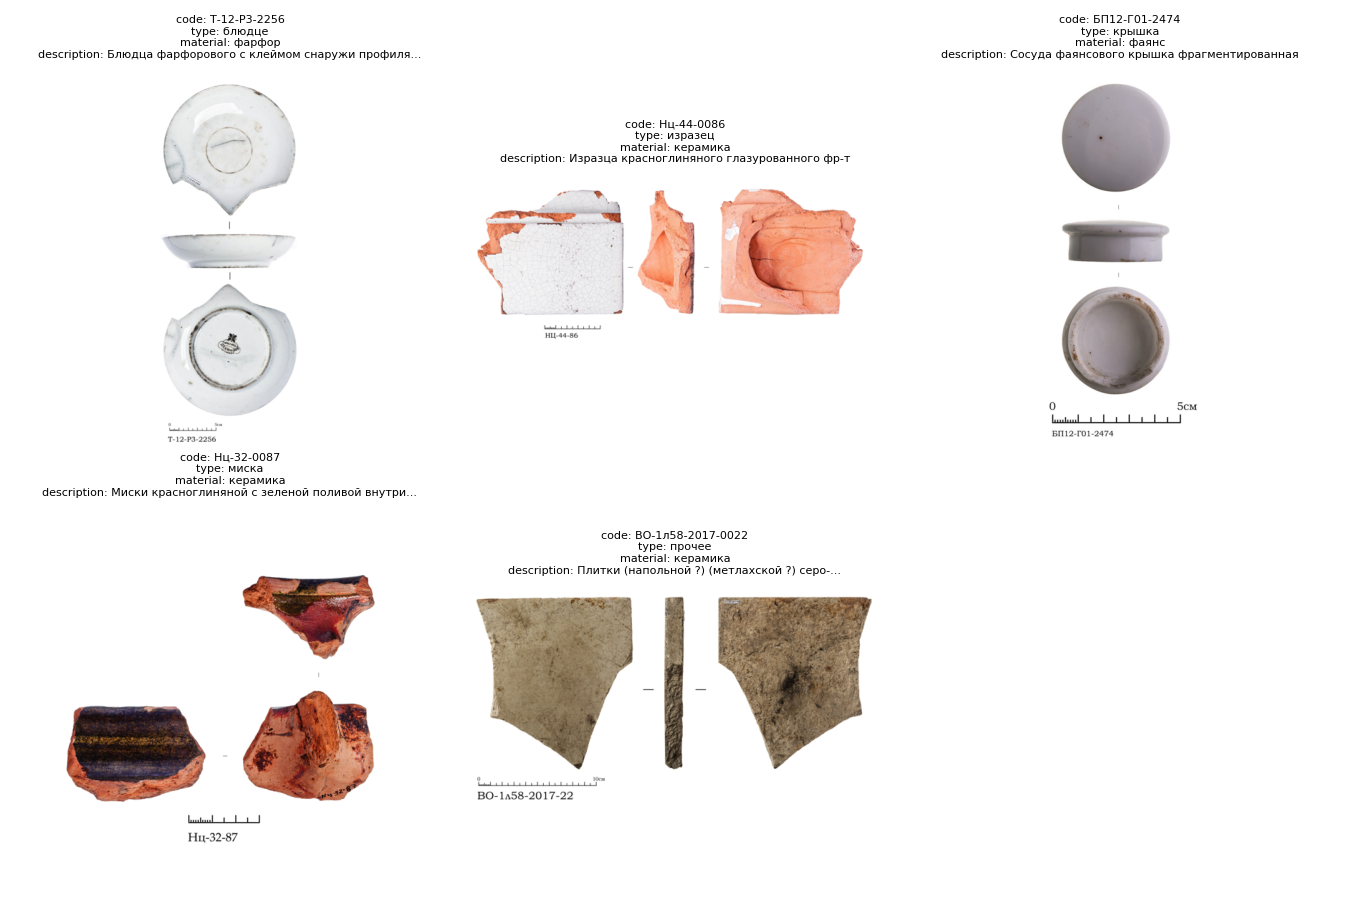

In [6]:
display(IPyImage(filename='artifacts/reports/data_report/row_image_examples.png'))


## 4. EDA — визуальные режимы и проблемные изображения

Heuristics в `image_analysis.py`: `foreground_ratio`, `bg_type`, `layout_mode`, `has_scale_bar`, `has_overlay_text`.


### sample_grid.png

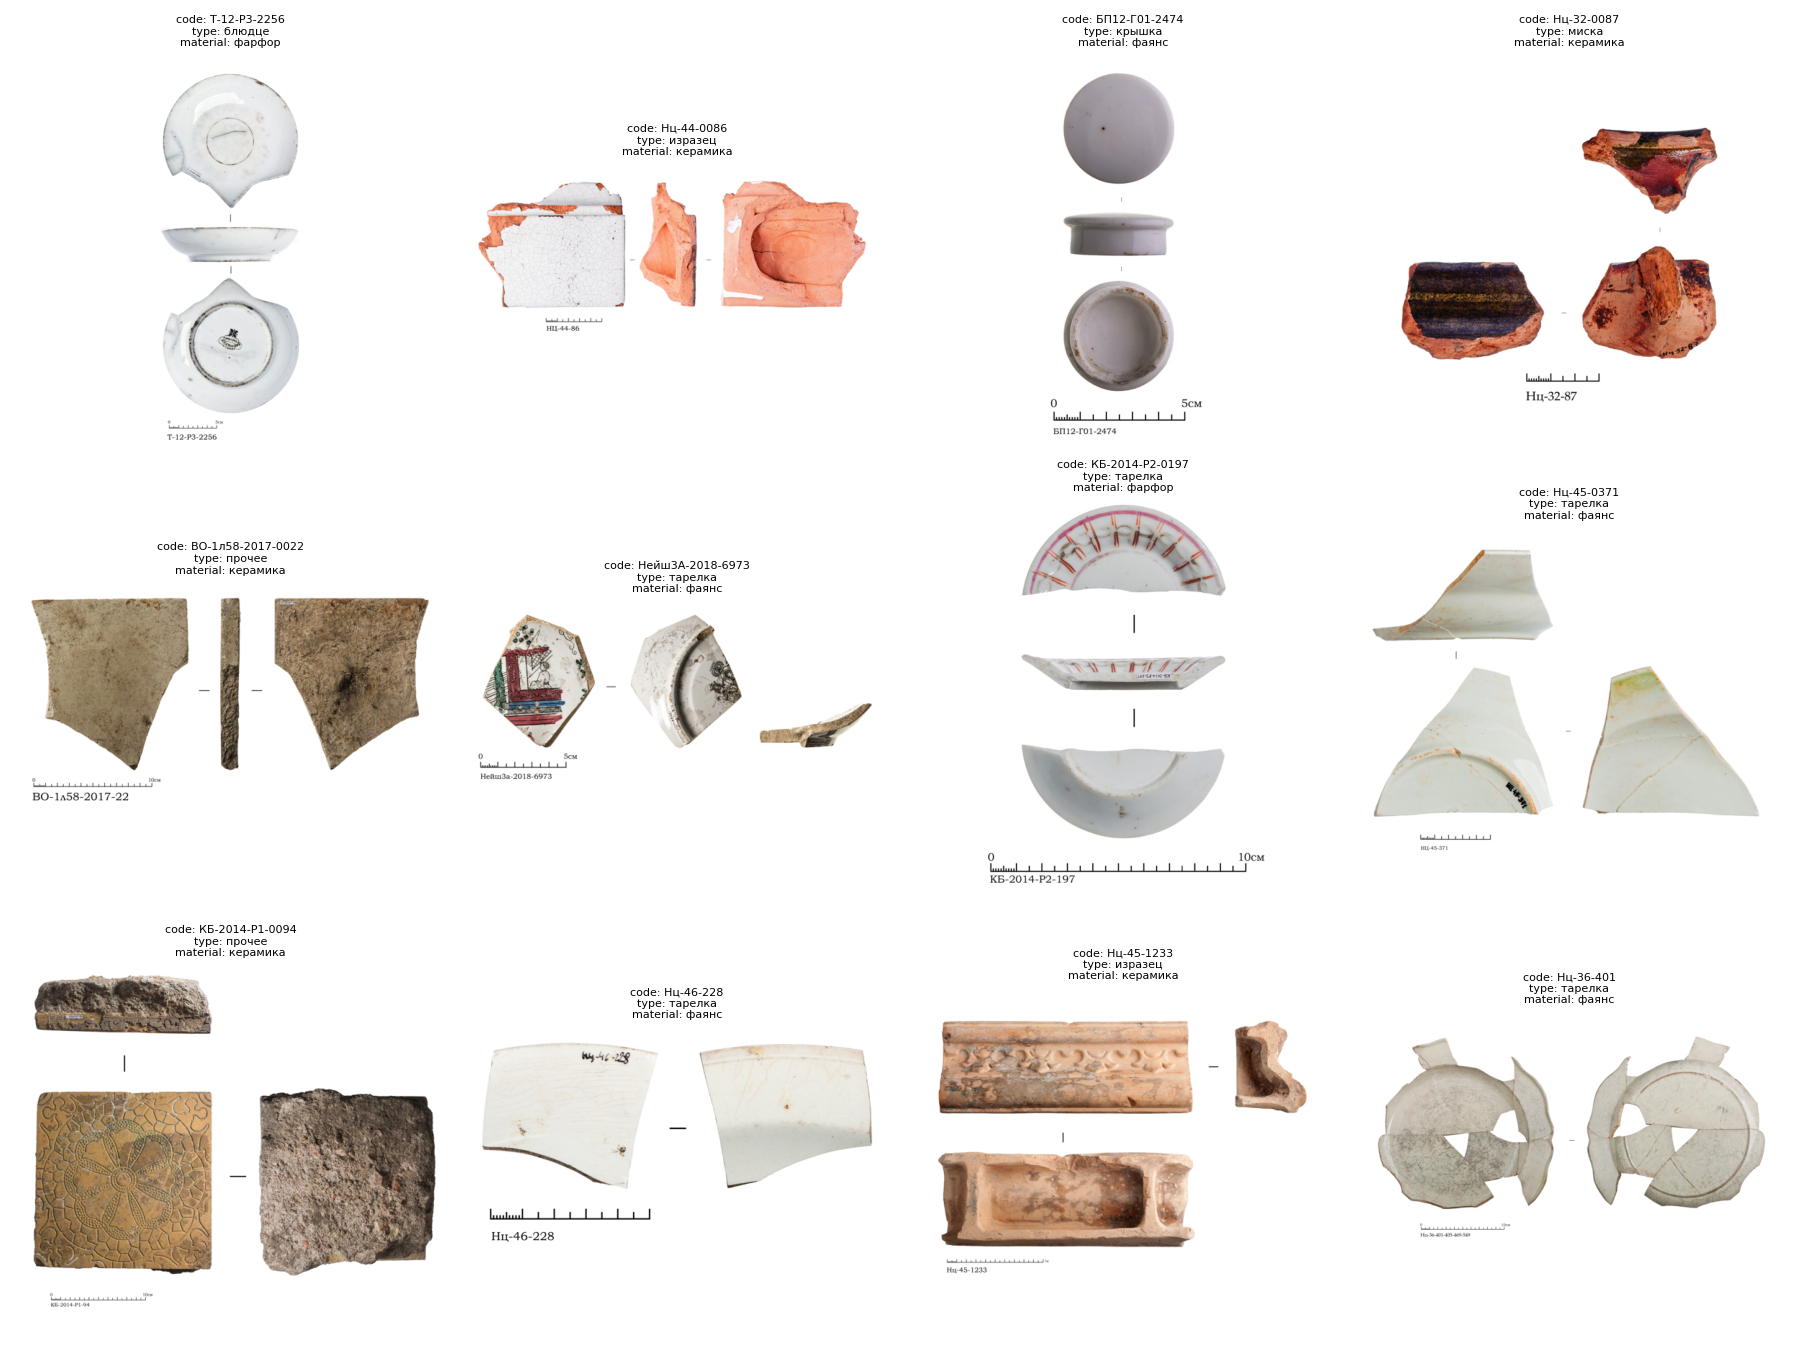

### layout_mode_examples.png

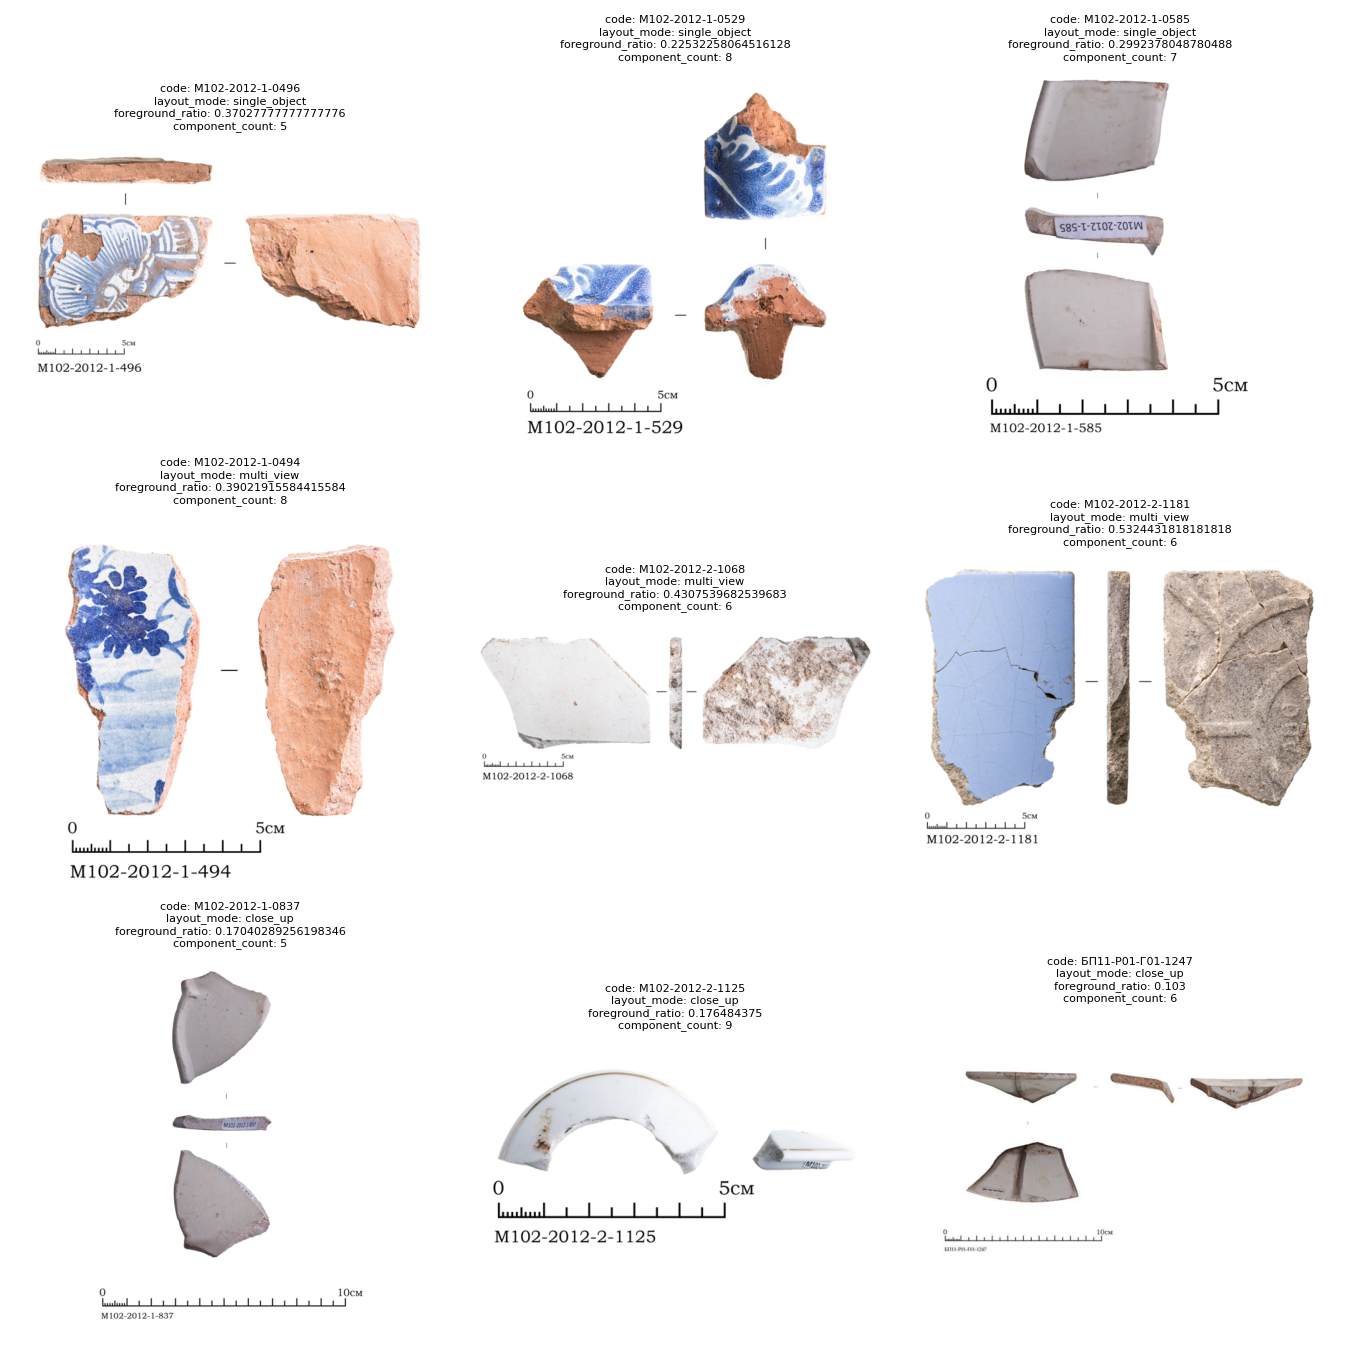

### problematic_images.png

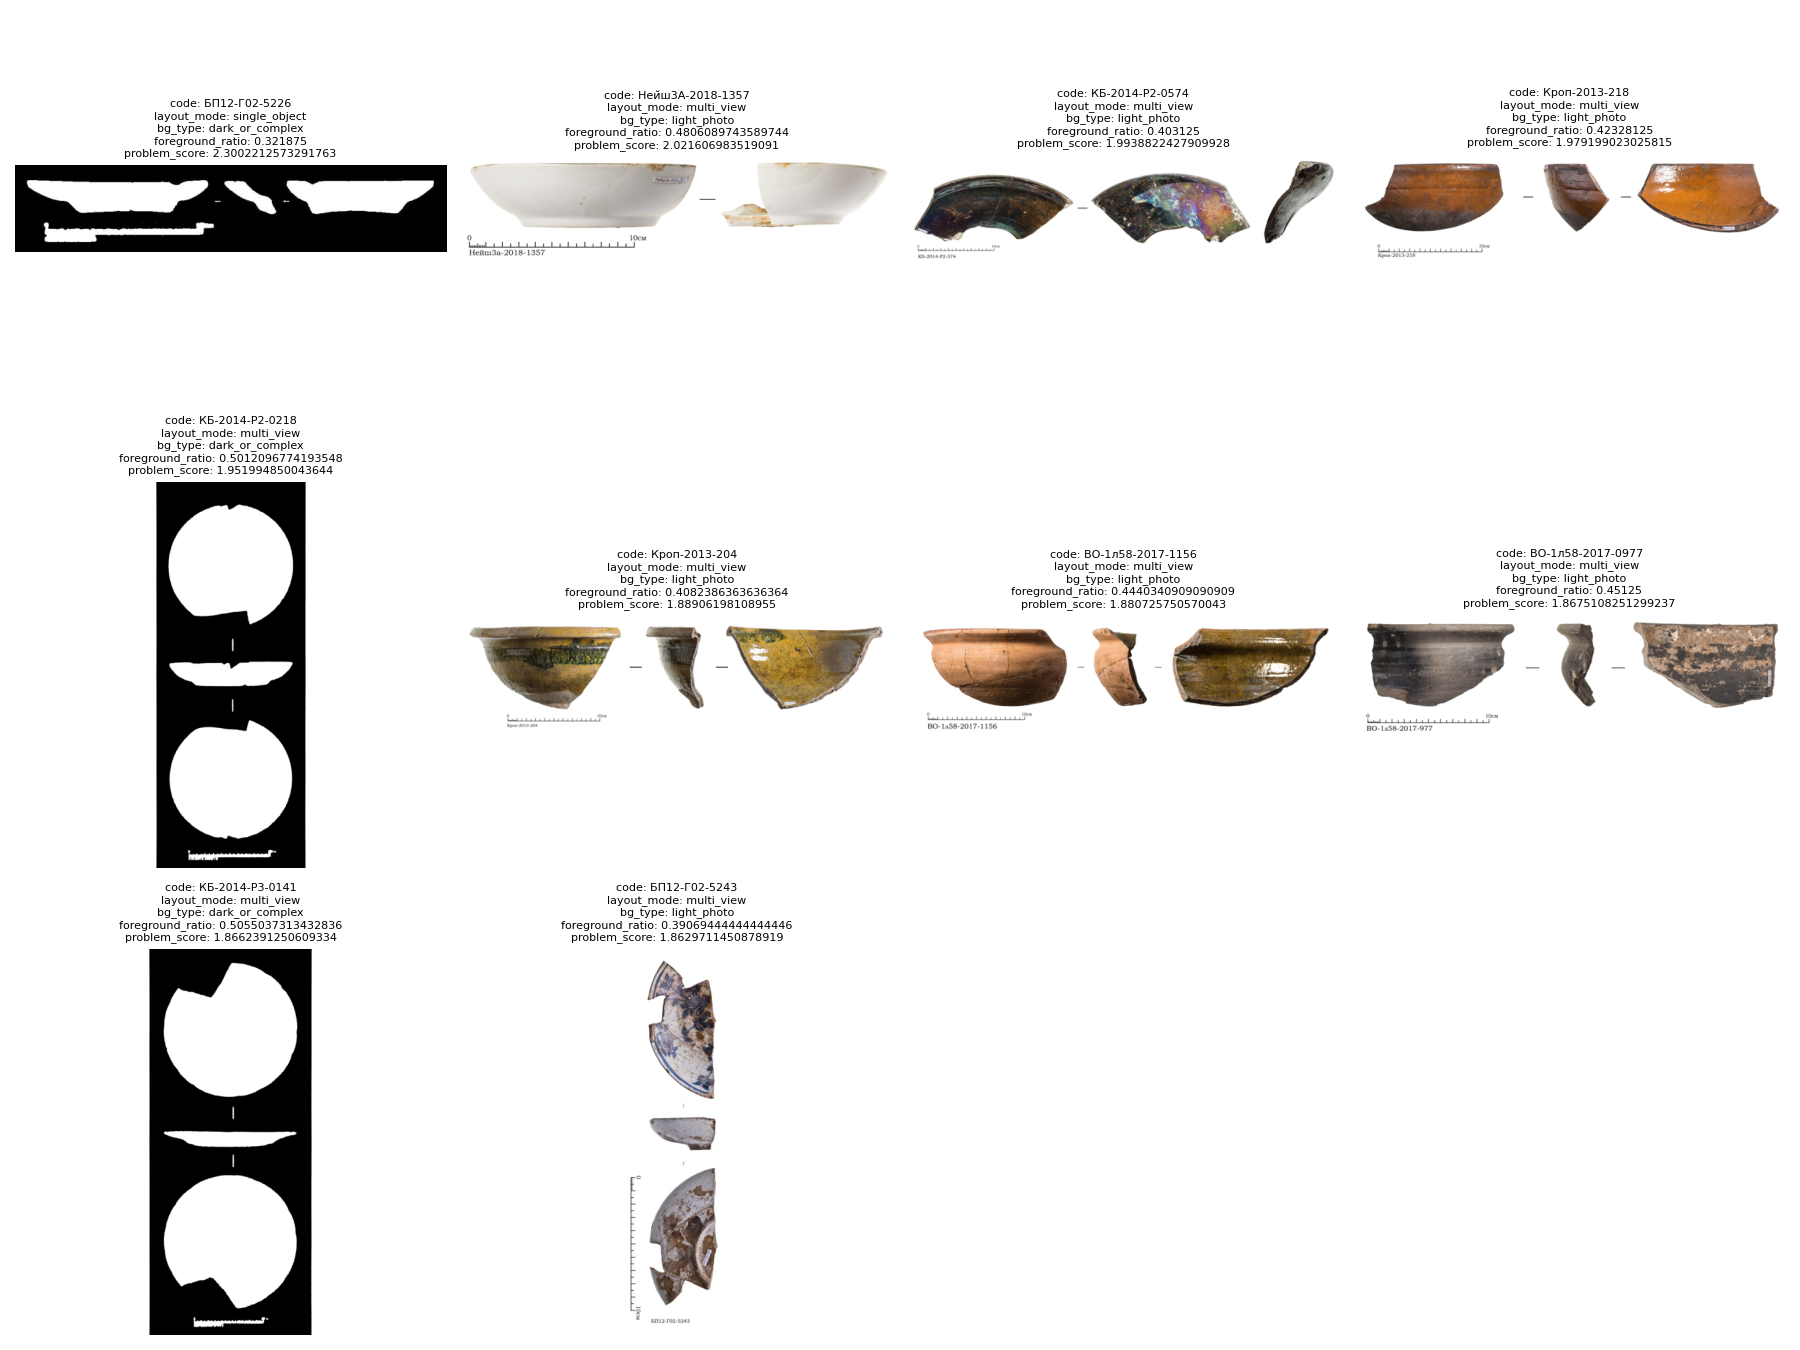

In [7]:
for fname in ['sample_grid.png','layout_mode_examples.png','problematic_images.png']:
    p = Path('artifacts/reports/data_report')/fname
    if p.exists():
        display(Markdown(f'### {fname}'))
        display(IPyImage(filename=str(p)))


In [8]:
heur = pd.read_csv('artifacts/reports/data_report/heuristic_summary.csv')
heur


,feature,value,count,ratio
0,layout_mode,single_object,1047,0.754867
1,layout_mode,multi_view,302,0.217736
2,layout_mode,close_up,38,0.027397
3,bg_type,white_uniform,1036,0.746936
4,bg_type,light_photo,322,0.232156
5,bg_type,dark_or_complex,29,0.020908
6,has_scale_bar,0,1386,0.999279
7,has_scale_bar,1,1,0.000721
8,has_overlay_text,0,1251,0.901947
9,has_overlay_text,1,136,0.098053


### Safe crop vs pad

Сравнение pad vs safe content-aware crop vs aggressive center-crop на изображении с большим белым фоном.
Safe crop сохраняет foreground, aggressive center-crop отрезает часть артефакта.
Скрипт: `src/similis_baseline/safe_crop_demo.py`.


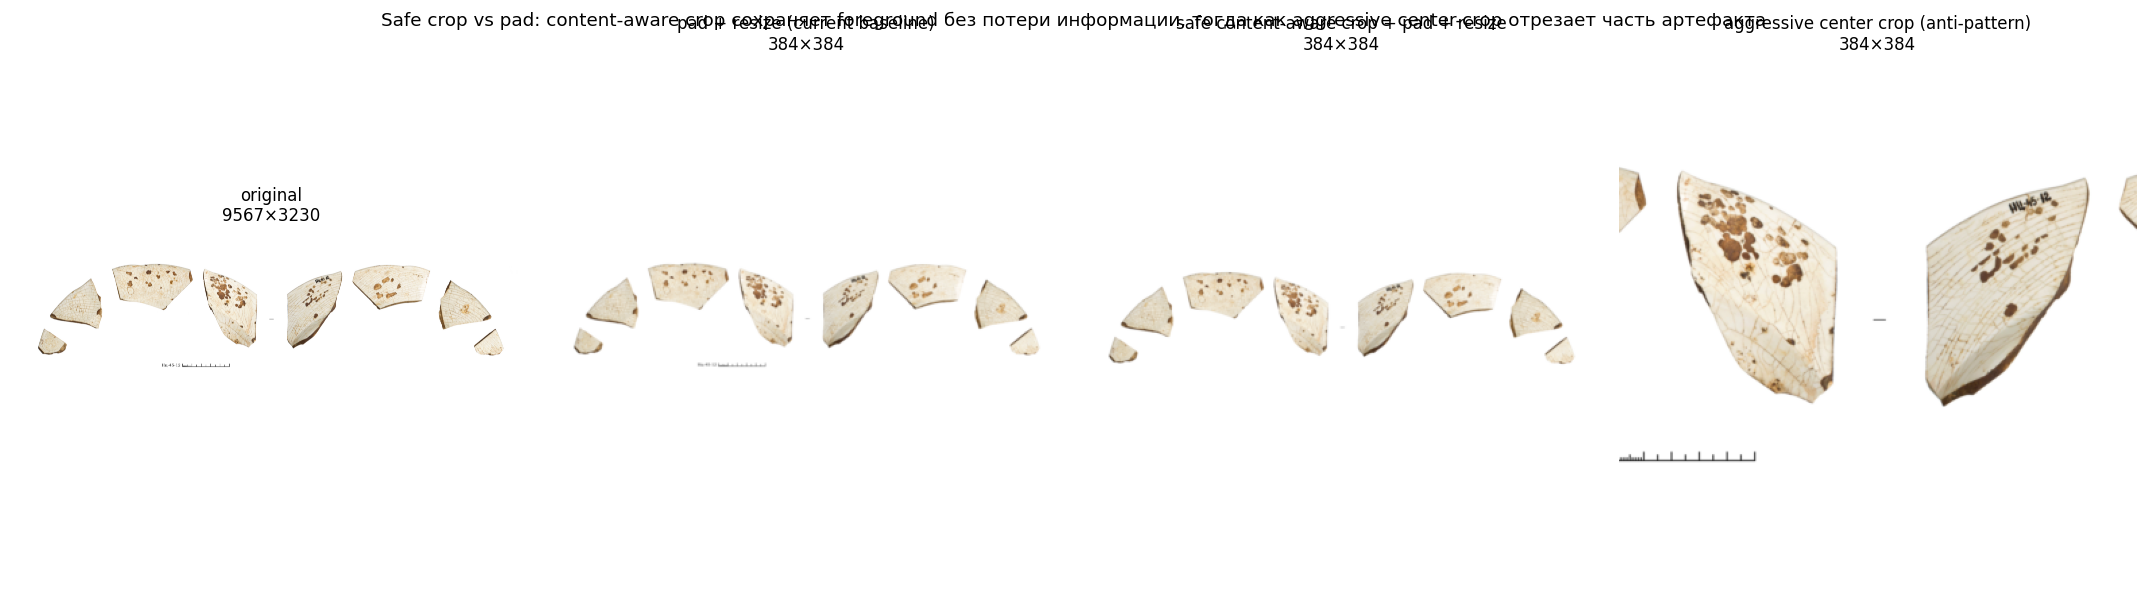

In [9]:
display(IPyImage(filename='artifacts/reports/transform_report/safe_crop_vs_pad.png'))


## 5. Выбор полей baseline и нормализация словарей

Baseline предсказывает 4 нормализованных поля: `type`, `part`, `integrity`, `material`.
Невизуальные поля (`size`, `cultlayer`, `survyear`, `execorg`, функция, датировка) сознательно исключены.


In [10]:
fc = pd.read_csv('artifacts/reports/data_report/field_candidates.csv')
fc


,candidate_field,visible_from_image,target_type,num_classes,missing_ratio,ambiguity_risk,baseline_decision,comment
0,type,yes,categorical,6,0.023071,medium,selected,core object category
1,part,partial,categorical,6,0.495314,high,selected,"useful, but noisy and often missing"
2,integrity,yes,categorical,2,0.000000,low,selected,strong visual cue
3,material,partial,categorical,5,0.020187,medium,selected,"visible, but sometimes probabilistic"
4,size,no,free_text,871,0.130497,high,excluded,requires external scale or card metadata
5,cultlayer,no,categorical,245,0.077866,high,excluded,"context field, not an image attribute"
6,survyear,no,categorical,6,0.617159,high,excluded,"excavation metadata, not visual content"


In [11]:
norm = pd.read_csv('artifacts/reports/data_report/normalization_examples.csv')
norm.head(20)


,field,raw_value,normalized_value,example_code,example_text
0,material,Белоглиняная керамика,керамика,Нев11-Г02-010,Тарелки белоглиняной с изумрудной поливой донц...
1,material,Глина,керамика,КБ-2014-Р1-0094,Плитка светлоглиняная напольная с растительным...
2,material,Керамика,керамика,М102-2012-1-0494,Изразца красноглиняного с белой поливой и коба...
3,material,Красноглиняная керамика,керамика,БП12-Г01-0732,Миски (?) красноглиняной орнаментированной с к...
4,material,Светлоглиняная керамика,керамика,БП12-Г01-5990,Крышки светлоглиняной края фр-т
5,material,Серолощеная керамика,керамика,БП12-Г01-5772,Сосуда серолощеного крышки края фр-т
6,material,Белый металл,прочее,БП11-Р01-Г01-1197,Крышка белого металла на бутылку с изображение...
7,material,Бронза,прочее,Нц-41-0031,Крышка бронзовая
8,material,Гранит,прочее,Нейш3А-2018-4071,Плитка пирогранитная квадратная клейменая
9,material,Дерево,прочее,БП12-Г01-7271,Миски деревянной профиль


In [12]:
policy = pd.read_csv('artifacts/reports/data_report/label_policy.csv')
policy


,case,handling
0,missing,keep dedicated *_is_missing flag and mask targ...
1,unknown,map unresolved values to coarse fallback class...
2,rare,do not collapse automatically; rely on coarse ...
3,uncertain,mark row with label_is_uncertain based on text...


## 6. Шаблон auto_description и правила confidence

Все поля confidence-gated (порог из `configs/baseline.yaml`). Если ни одно поле не прошло порог, возвращается
fallback `не удалось уверенно собрать описание`.

Порядок полей в auto_description:
1. `type`
2. `material`
3. `part`
4. слово `фрагмент`, если `integrity=фрагмент` и confidence прошёл порог.


In [13]:
import yaml
with open('configs/baseline.yaml', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)
print('confidence_thresholds:', cfg['confidence_thresholds'])
print('fields              :', cfg['fields'])


confidence_thresholds: {'type': 0.45, 'part': 0.5, 'integrity': 0.55, 'material': 0.5}
fields              : ['type', 'part', 'integrity', 'material']


In [14]:
infer = pd.read_csv('artifacts/preds/inference.csv')
cols = ['image_file','auto_description','pred_type','pred_material','pred_part','pred_integrity']
conf_cols = [c for c in infer.columns if c.startswith('confidence_')]
infer[cols + conf_cols].head(10)


,image_file,auto_description,pred_type,pred_material,pred_part,pred_integrity,confidence_type,confidence_part,confidence_integrity,confidence_material
0,orig.jpg,изразец керамика фрагмент,изразец,керамика,профиль,фрагмент,0.998903,0.455580,0.999724,0.999721
1,БП11-Р01-Г01-0944_orig.jpg,тарелка фаянс профиль фрагмент,тарелка,фаянс,профиль,фрагмент,0.998960,0.813033,0.999989,0.993761
2,БП11-Р01-Г01-1055_orig.jpg,изразец керамика профиль фрагмент,изразец,керамика,профиль,фрагмент,0.997387,0.998212,0.996267,0.999979
3,БП11-Р01-Г01-1065_orig.jpg,тарелка фаянс донце фрагмент,тарелка,фаянс,донце,фрагмент,0.997165,0.962436,0.999901,0.991949
4,БП11-Р01-Г01-1137_orig.jpg,крышка керамика профиль фрагмент,крышка,керамика,профиль,фрагмент,0.999124,0.963508,0.999777,0.964483
5,БП11-Р01-Г01-1192_orig.jpg,изразец керамика профиль фрагмент,изразец,керамика,профиль,фрагмент,0.999975,0.744958,0.999484,0.999956
6,БП11-Р01-Г01-1197_orig.jpg,крышка керамика профиль фрагмент,крышка,керамика,профиль,фрагмент,0.997422,0.676032,0.999520,0.811456
7,БП11-Р01-Г01-1247_orig.jpg,тарелка фаянс прочее фрагмент,тарелка,фаянс,прочее,фрагмент,0.997829,0.979963,0.999459,0.987415
8,БП11-Р01-Г01-1248_orig.jpg,тарелка фаянс донце фрагмент,тарелка,фаянс,донце,фрагмент,0.999259,0.994456,0.999770,0.992129
9,БП11-Р01-Г01-1251_orig.jpg,тарелка фаянс донце фрагмент,тарелка,фаянс,донце,фрагмент,0.974570,0.959474,0.999950,0.896009


In [15]:
# 1 пример с низкой confidence -> поле опущено или fallback
low = infer.copy()
low['min_conf'] = low[conf_cols].min(axis=1)
low.sort_values('min_conf').head(5)[cols + ['min_conf']]


,image_file,auto_description,pred_type,pred_material,pred_part,pred_integrity,min_conf
588,М102-2012-1-0496_orig.jpg,изразец керамика фрагмент,изразец,керамика,прочее,фрагмент,0.248000
739,Нейш3А-2018-0868_orig.jpg,изразец керамика фрагмент,изразец,керамика,венчик,фрагмент,0.272336
332,КБ-2014-Р1-1489_orig.jpg,изразец керамика фрагмент,изразец,керамика,донце,фрагмент,0.280208
587,М102-2012-1-0494_orig.jpg,изразец керамика фрагмент,изразец,керамика,донце,фрагмент,0.284788
658,Нев11-Г03-178_orig.jpg,изразец керамика фрагмент,изразец,керамика,венчик,фрагмент,0.285035


## 7. Модель — multi-task ConvNeXt-Tiny

Backbone + по одной classification head на каждое поле; logits на выходе (без softmax). Описание — `src/similis_baseline/model.py`.


In [16]:
with open('artifacts/reports/model_summary.json', encoding='utf-8') as f:
    ms = json.load(f)
ms


{'checkpoint_path': 'artifacts/checkpoints/best.pt',
 'backbone': 'convnext_tiny',
 'image_size': 384,
 'fields': ['type', 'part', 'integrity', 'material'],
 'epoch': 7,
 'best_metric': 0.8190997315494435,
 'total_params': 27834739,
 'backbone_params': 27820128,
 'heads_params': 14611,
 'trainable_params': 27834739}

## 8. One-batch debug и tiny-overfit (sanity-checks)

- `one_batch_debug.py` — shapes/dtypes, loss/acc по каждому полю на одном батче.
- `tiny_overfit.py` — на 32–64 объектах модель должна заметно переобучиться.
Артефакты лежат в `artifacts/reports/tiny_overfit_type_clean_current/`.


### subset_loss.png

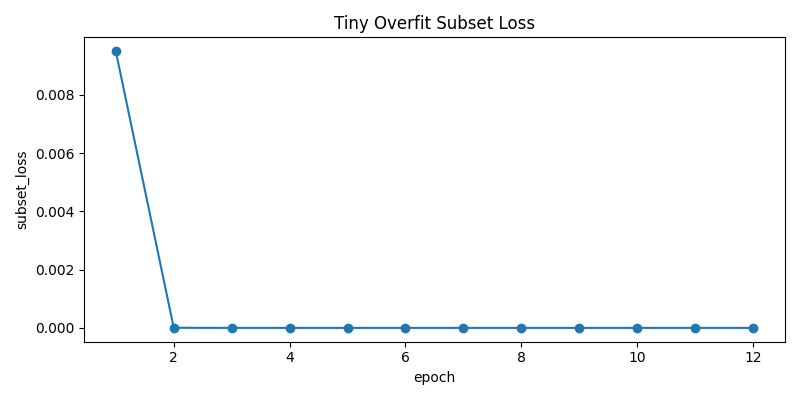

### train_accuracy.png

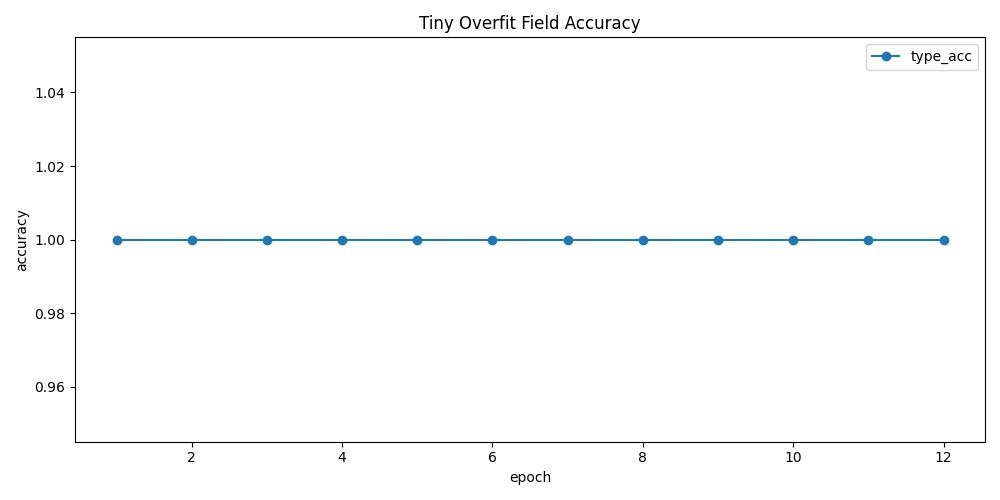

### train_loss.png

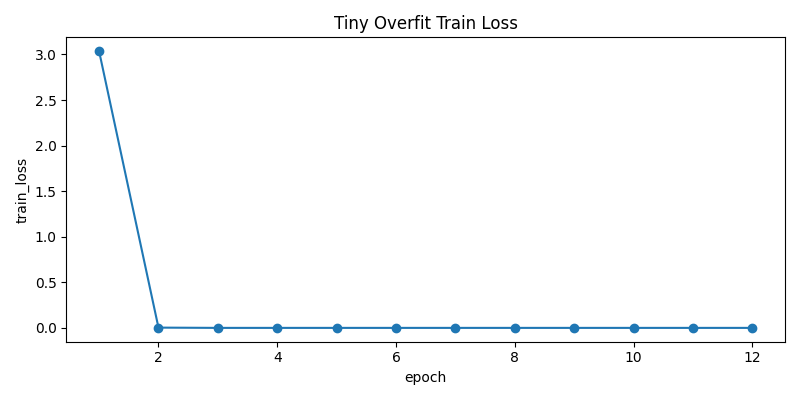

### train_macro_f1.png

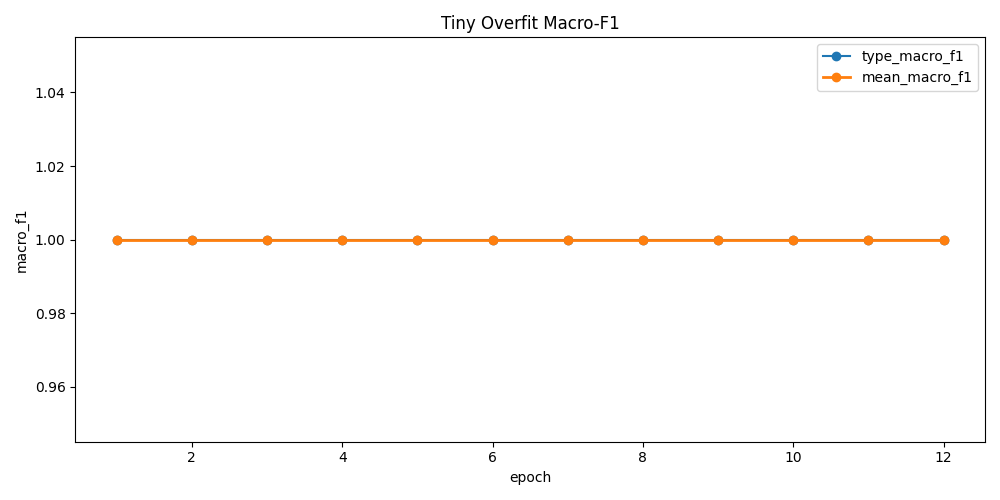

In [17]:
tof_dir = Path('artifacts/reports/tiny_overfit_type_clean_current')
if tof_dir.exists():
    for png in sorted(tof_dir.glob('*.png')):
        display(Markdown(f'### {png.name}'))
        display(IPyImage(filename=str(png)))
else:
    print('tiny_overfit dir missing')


## 9. Полный train/eval цикл — кривые обучения

Лог `artifacts/reports/train_log.csv` соответствует текущему `artifacts/checkpoints/best.pt`.


In [18]:
import matplotlib.pyplot as plt
log = pd.read_csv('artifacts/reports/train_log.csv')
log


,epoch,train_loss,val_loss,type_acc,type_macro_f1,part_acc,part_macro_f1,integrity_acc,integrity_macro_f1,material_acc,material_macro_f1,mean_macro_f1,backbone_trainable,backbone_lr,head_lr
0,1,0.753439,0.539862,0.717172,0.671260,0.518868,0.441165,0.894231,0.627604,0.777228,0.659867,0.599974,0,0.000000,0.000300
1,2,0.472252,0.445337,0.732323,0.699429,0.641509,0.542387,0.894231,0.647675,0.816832,0.756052,0.661386,0,0.000000,0.000289
2,3,0.455964,0.375988,0.782828,0.762669,0.632075,0.553044,0.918269,0.703729,0.826733,0.835708,0.713787,1,0.000030,0.000256
3,4,0.251784,0.309901,0.843434,0.824955,0.726415,0.618472,0.927885,0.702942,0.876238,0.892297,0.759666,1,0.000028,0.000208
4,5,0.120478,0.417152,0.752525,0.732080,0.707547,0.725870,0.961538,0.789899,0.772277,0.775252,0.755775,1,0.000023,0.000150
5,6,0.055594,0.313185,0.838384,0.834594,0.792453,0.799763,0.956731,0.751823,0.841584,0.861195,0.811844,1,0.000016,0.000093
6,7,0.018641,0.305236,0.848485,0.841857,0.745283,0.771015,0.956731,0.751823,0.896040,0.911703,0.819100,1,0.000008,0.000045
7,8,0.008662,0.325049,0.843434,0.839653,0.726415,0.758254,0.956731,0.751823,0.876238,0.895242,0.811243,1,0.000003,0.000012
8,9,0.005626,0.317495,0.843434,0.839653,0.745283,0.770195,0.956731,0.751823,0.886139,0.902632,0.816076,1,0.000001,0.000001


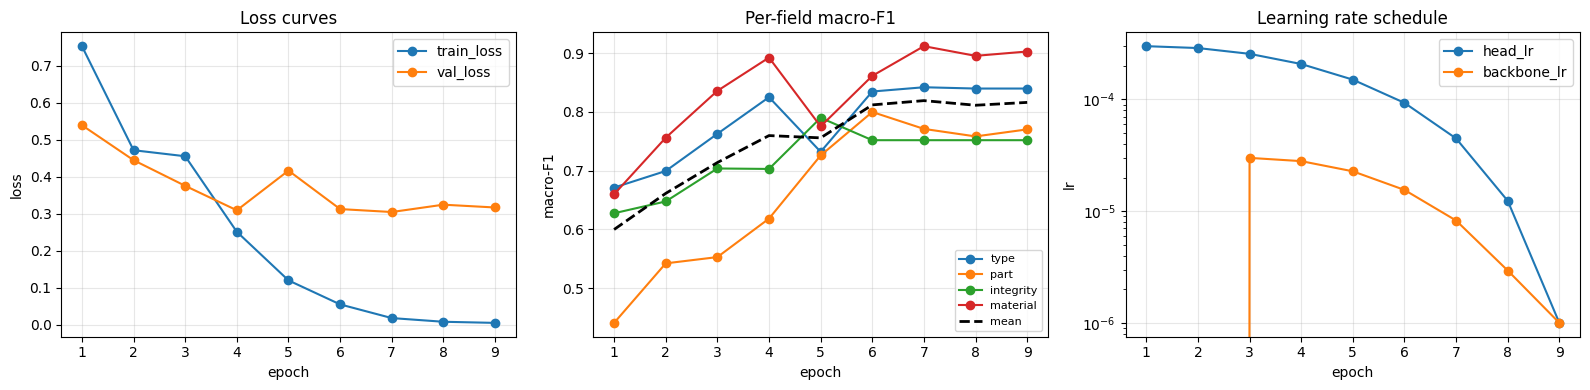

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(log['epoch'], log['train_loss'], 'o-', label='train_loss')
axes[0].plot(log['epoch'], log['val_loss'], 'o-', label='val_loss')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[0].set_title('Loss curves')
for f in ['type','part','integrity','material']:
    col = f'{f}_macro_f1'
    if col in log.columns:
        axes[1].plot(log['epoch'], log[col], 'o-', label=f)
axes[1].plot(log['epoch'], log['mean_macro_f1'], 'k--', label='mean', linewidth=2)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('macro-F1'); axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)
axes[1].set_title('Per-field macro-F1')
axes[2].plot(log['epoch'], log['head_lr'], 'o-', label='head_lr')
axes[2].plot(log['epoch'], log['backbone_lr'], 'o-', label='backbone_lr')
axes[2].set_xlabel('epoch'); axes[2].set_ylabel('lr'); axes[2].set_yscale('log'); axes[2].legend(); axes[2].grid(alpha=.3)
axes[2].set_title('Learning rate schedule')
plt.tight_layout(); plt.show()


## 10. Метрики на валидации + confusion matrices


In [20]:
with open('artifacts/reports/val_detailed/metrics.json', encoding='utf-8') as f:
    val_metrics = json.load(f)
val_metrics


{'split': 'val',
 'rows': 208,
 'val_loss': 0.3052355910723026,
 'type_acc': 0.8484848484848485,
 'type_macro_f1': 0.8418573681622353,
 'part_acc': 0.7452830188679245,
 'part_macro_f1': 0.7710151802656546,
 'integrity_acc': 0.9567307692307693,
 'integrity_macro_f1': 0.7518228821423836,
 'material_acc': 0.8960396039603961,
 'material_macro_f1': 0.9117034956275001,
 'mean_macro_f1': 0.8190997315494435}

In [21]:
cw = pd.read_csv('artifacts/reports/val_detailed/classwise_metrics.csv')
cw


,field,label_idx,label,precision,recall,f1,support
0,type,0,блюдце,0.812500,0.666667,0.732394,39
1,type,1,изразец,0.867925,0.978723,0.920000,47
2,type,2,крышка,0.947368,0.900000,0.923077,20
3,type,3,миска,0.785714,0.785714,0.785714,14
4,type,4,прочее,0.000000,0.000000,0.000000,0
5,type,5,тарелка,0.837500,0.858974,0.848101,78
6,part,0,венчик,0.680000,0.739130,0.708333,23
7,part,1,донце,0.923077,0.666667,0.774194,36
8,part,2,профиль,0.638298,0.789474,0.705882,38
9,part,3,прочее,1.000000,0.500000,0.666667,2


### val: type

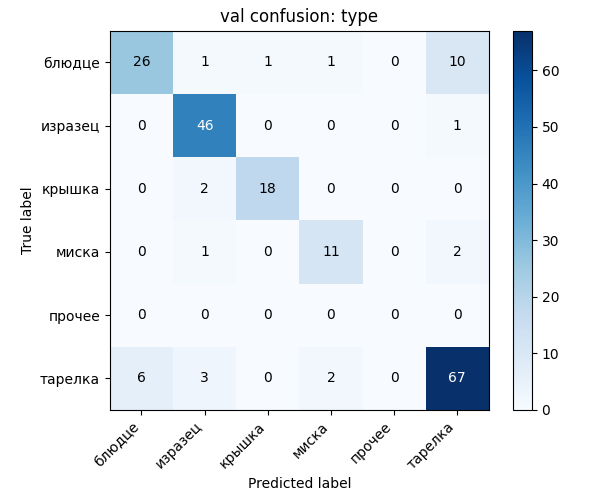

### val: part

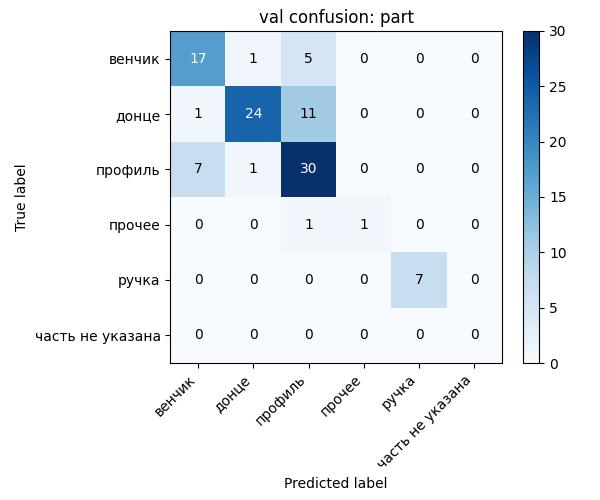

### val: integrity

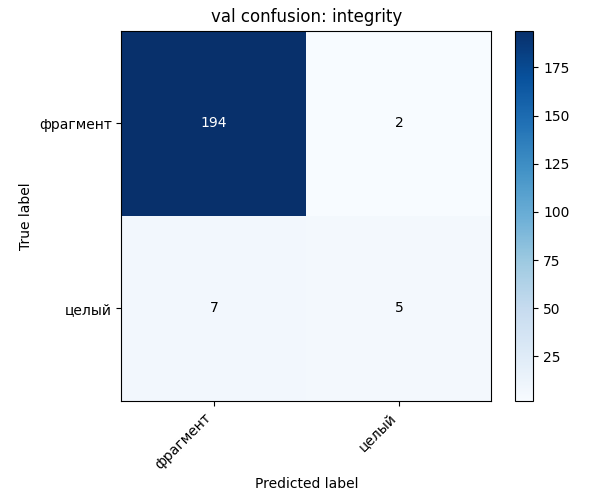

### val: material

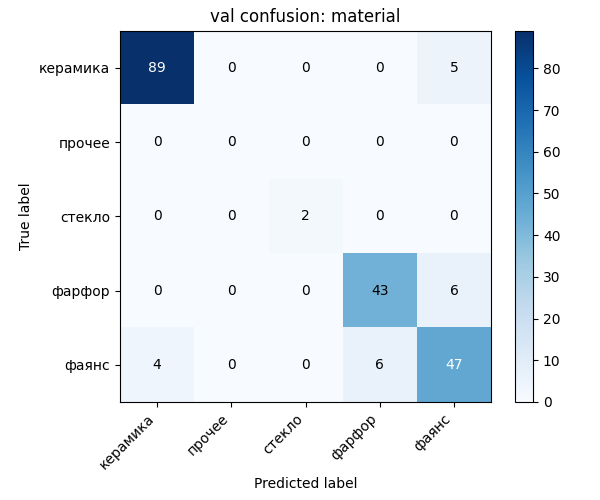

In [22]:
for f in ['type','part','integrity','material']:
    p = Path('artifacts/reports/val_detailed') / f'confusion_{f}.png'
    if p.exists():
        display(Markdown(f'### val: {f}'))
        display(IPyImage(filename=str(p)))


In [23]:
with open('artifacts/reports/val_detailed/best_worst_classes.json', encoding='utf-8') as f:
    bw = json.load(f)
bw


{'type': {'best': [{'field': 'type',
    'label_idx': 2,
    'label': 'крышка',
    'precision': 0.9473684210526315,
    'recall': 0.9,
    'f1': 0.9230769230769231,
    'support': 20},
   {'field': 'type',
    'label_idx': 1,
    'label': 'изразец',
    'precision': 0.8679245283018868,
    'recall': 0.9787234042553191,
    'f1': 0.92,
    'support': 47},
   {'field': 'type',
    'label_idx': 5,
    'label': 'тарелка',
    'precision': 0.8375,
    'recall': 0.8589743589743589,
    'f1': 0.8481012658227848,
    'support': 78},
   {'field': 'type',
    'label_idx': 3,
    'label': 'миска',
    'precision': 0.7857142857142857,
    'recall': 0.7857142857142857,
    'f1': 0.7857142857142857,
    'support': 14},
   {'field': 'type',
    'label_idx': 0,
    'label': 'блюдце',
    'precision': 0.8125,
    'recall': 0.6666666666666666,
    'f1': 0.7323943661971831,
    'support': 39}],
  'worst': [{'field': 'type',
    'label_idx': 0,
    'label': 'блюдце',
    'precision': 0.8125,
    'recall'

## 11. Метрики на открытом тесте


In [24]:
with open('artifacts/reports/test_detailed/metrics.json', encoding='utf-8') as f:
    test_metrics = json.load(f)
test_metrics


{'split': 'test',
 'rows': 209,
 'val_loss': 0.3943466316085115,
 'type_acc': 0.8058252427184466,
 'type_macro_f1': 0.7556355939987653,
 'part_acc': 0.7155963302752294,
 'part_macro_f1': 0.5890394682085989,
 'integrity_acc': 0.9282296650717703,
 'integrity_macro_f1': 0.6239654551997121,
 'material_acc': 0.8695652173913043,
 'material_macro_f1': 0.8404184259215333,
 'mean_macro_f1': 0.7022647358321524}

### test: type

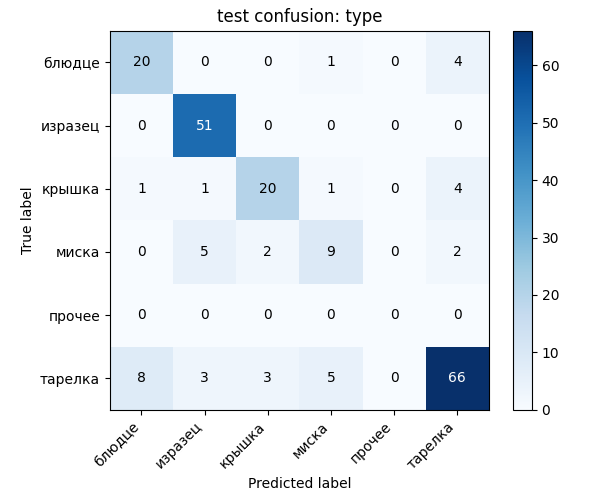

### test: part

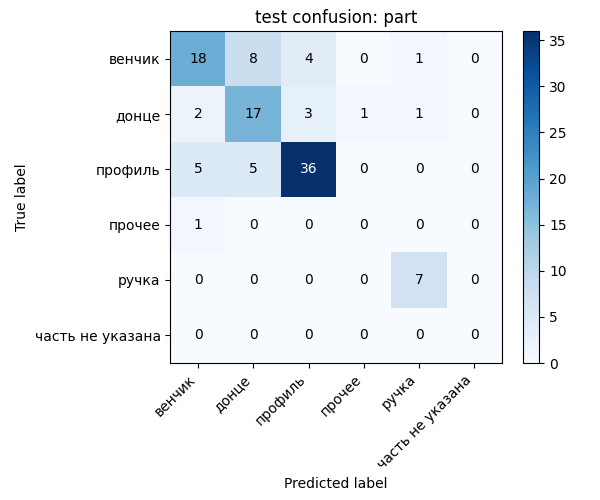

### test: integrity

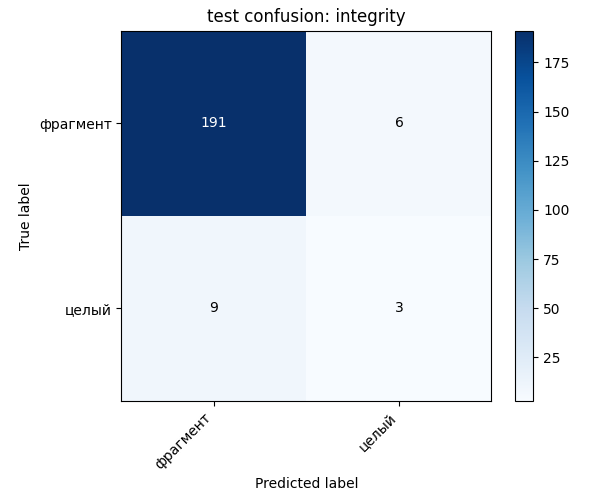

### test: material

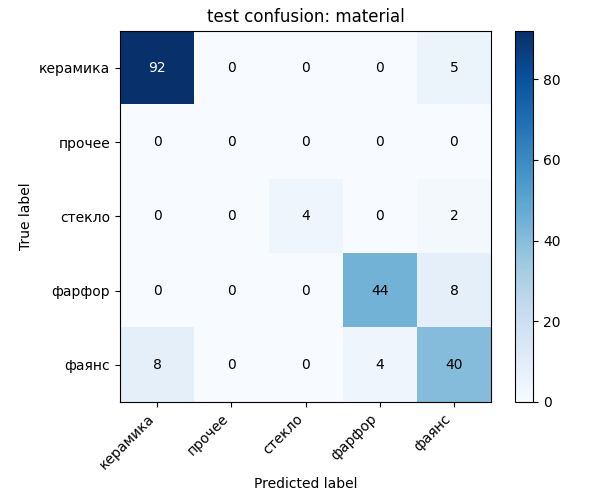

In [25]:
for f in ['type','part','integrity','material']:
    p = Path('artifacts/reports/test_detailed') / f'confusion_{f}.png'
    if p.exists():
        display(Markdown(f'### test: {f}'))
        display(IPyImage(filename=str(p)))


## 12. Error analysis по факторам


In [26]:
for split in ['val','test']:
    p = Path(f'artifacts/reports/{split}_error_factors/factor_breakdown.csv')
    if p.exists():
        display(Markdown(f'### {split} factor_breakdown'))
        display(pd.read_csv(p))


### val factor_breakdown

,factor,value,rows,any_error_rate,auto_description_match_rate,mean_num_field_errors,mean_confidence,type_acc_labeled,part_acc_labeled,integrity_acc_labeled,material_acc_labeled
0,bg_type,white_uniform,146,0.267123,0.301370,0.328767,0.898141,0.883212,0.790323,0.965753,0.900709
1,bg_type,light_photo,56,0.482143,0.303571,0.553571,0.890434,0.818182,0.675000,0.928571,0.927273
2,bg_type,dark_or_complex,6,1.000000,0.000000,1.333333,0.908099,0.333333,0.750000,1.000000,0.500000
3,foreground_ratio_bin,ge_0.30,129,0.379845,0.310078,0.465116,0.894824,0.826446,0.764706,0.930233,0.888000
4,foreground_ratio_bin,0.15_0.30,74,0.297297,0.243243,0.351351,0.899266,0.890411,0.685714,1.000000,0.904110
5,foreground_ratio_bin,0.08_0.15,5,0.200000,0.600000,0.200000,0.892713,0.750000,1.000000,1.000000,1.000000
6,has_overlay_text,0,188,0.356383,0.292553,0.425532,0.896424,0.850000,0.750000,0.952128,0.890710
7,has_overlay_text,1,20,0.250000,0.300000,0.350000,0.895693,0.833333,0.700000,1.000000,0.947368
8,has_scale_bar,0,207,0.342995,0.294686,0.415459,0.896481,0.852792,0.745283,0.956522,0.895522
9,has_scale_bar,1,1,1.000000,0.000000,1.000000,0.870011,0.000000,NaN,1.000000,1.000000


### test factor_breakdown

,factor,value,rows,any_error_rate,auto_description_match_rate,mean_num_field_errors,mean_confidence,type_acc_labeled,part_acc_labeled,integrity_acc_labeled,material_acc_labeled
0,bg_type,white_uniform,157,0.388535,0.343949,0.496815,0.885272,0.832258,0.740260,0.949045,0.845161
1,bg_type,light_photo,49,0.551020,0.285714,0.653061,0.877789,0.729167,0.700000,0.857143,0.938776
2,bg_type,dark_or_complex,3,1.000000,0.000000,1.000000,0.884972,0.666667,0.000000,1.000000,1.000000
3,foreground_ratio_bin,ge_0.30,128,0.437500,0.320312,0.531250,0.880850,0.793651,0.718750,0.921875,0.890625
4,foreground_ratio_bin,0.15_0.30,79,0.443038,0.329114,0.569620,0.887017,0.820513,0.704545,0.936709,0.831169
5,foreground_ratio_bin,0.08_0.15,2,0.000000,0.500000,0.000000,0.915559,1.000000,1.000000,1.000000,1.000000
6,has_overlay_text,0,193,0.450777,0.305699,0.559585,0.882803,0.801047,0.700000,0.927461,0.863874
7,has_overlay_text,1,16,0.250000,0.562500,0.312500,0.892078,0.866667,0.888889,0.937500,0.937500
8,has_scale_bar,0,209,0.435407,0.325359,0.540670,0.883513,0.805825,0.715596,0.928230,0.869565
9,layout_mode,single_object,154,0.448052,0.324675,0.571429,0.885129,0.809211,0.690476,0.922078,0.861842


In [27]:
for split in ['val','test']:
    p = Path(f'artifacts/reports/{split}_error_factors/error_reason_breakdown.csv')
    if p.exists():
        display(Markdown(f'### {split} error_reason_breakdown'))
        display(pd.read_csv(p))


### val error_reason_breakdown

,error_reason,rows,any_error_rate,auto_description_match_rate,mean_num_field_errors,mean_confidence
0,correct,136,0.0,0.448529,0.000000,0.911648
1,other_model_error,42,1.0,0.000000,1.071429,0.891627
2,layout_complexity,12,1.0,0.000000,1.166667,0.864288
3,visual_ambiguity_low_confidence,8,1.0,0.000000,1.875000,0.699365
4,shortcut_risk_layout,4,1.0,0.000000,1.250000,0.887207
5,hard_visual_conditions,3,1.0,0.000000,1.666667,0.915810
6,uncertain_or_label_noise,3,1.0,0.000000,1.000000,0.915478


### test error_reason_breakdown

,error_reason,rows,any_error_rate,auto_description_match_rate,mean_num_field_errors,mean_confidence
0,correct,118,0.0,0.576271,0.000000,0.907066
1,other_model_error,53,1.0,0.000000,1.207547,0.876511
2,layout_complexity,18,1.0,0.000000,1.055556,0.873498
3,visual_ambiguity_low_confidence,11,1.0,0.000000,1.545455,0.717090
4,uncertain_or_label_noise,6,1.0,0.000000,1.500000,0.828896
5,hard_visual_conditions,2,1.0,0.000000,1.000000,0.906424
6,shortcut_risk_layout,1,1.0,0.000000,2.000000,0.768289


## 13. Ablation study

3 сравнимых CPU-эксперимента: `pad+class_weights`, `pad+no_class_weights`, `stretch+class_weights` при
`image_size=224`, `epochs=4`, `freeze_backbone_epochs=1`.


In [28]:
abl = pd.read_csv('artifacts/ablations/report/ablation_results.csv')
abl


,experiment,config_path,backbone,image_size,epochs,freeze_backbone_epochs,preprocess_mode,use_class_weights,best_epoch,logged_best_val_mean_macro_f1,val_mean_macro_f1,val_type_macro_f1,val_part_macro_f1,val_integrity_macro_f1,val_material_macro_f1,test_mean_macro_f1
0,ablation_cpu_stretch,configs/ablation_cpu_stretch.yaml,convnext_tiny,224,4,1,stretch,True,4,0.767585,0.767585,0.781454,0.719645,0.693667,0.875572,0.671190
1,ablation_cpu_no_class_weights,configs/ablation_cpu_no_class_weights.yaml,convnext_tiny,224,4,1,pad,False,4,0.733146,0.733146,0.778039,0.583596,0.789899,0.781051,0.616280
2,ablation_cpu_base,configs/ablation_cpu_base.yaml,convnext_tiny,224,4,1,pad,True,4,0.702051,0.702051,0.746767,0.631556,0.712608,0.717271,0.701029


In [29]:
summary_md = Path('artifacts/ablations/report/ablation_summary.md').read_text(encoding='utf-8')
display(Markdown(summary_md))


# Ablation Study

Best experiment by validation macro-F1: `ablation_cpu_stretch`

| experiment                    | preprocess | class_weights | image_size | epochs | best_epoch | val_mean_macro_f1 |
|-------------------------------|------------|---------------|------------|--------|------------|-------------------|
| ablation_cpu_stretch          | stretch    | True          | 224        | 4      | 4          | 0.7676            |
| ablation_cpu_no_class_weights | pad        | False         | 224        | 4      | 4          | 0.7331            |
| ablation_cpu_base             | pad        | True          | 224        | 4      | 4          | 0.7021            |


## 14. Финальная модель — удачные и неудачные кейсы


In [30]:
succ = pd.read_csv('artifacts/reports/test_detailed/successful_examples.csv').head(5)
fail = pd.read_csv('artifacts/reports/test_detailed/failed_examples.csv').head(5)
display(Markdown('### test: 5 удачных'))
display(succ)
display(Markdown('### test: 5 неудачных'))
display(fail)


### test: 5 удачных

,image_file,group_key,gt_type,pred_type,confidence_type,type_mask,correct_type,gt_part,pred_part,confidence_part,...,pred_material,confidence_material,material_mask,correct_material,pred_auto_description,gt_auto_description,auto_description_match,num_field_errors,mean_confidence,any_error
0,data/raw/images/Нц-52-389_orig.jpg,Нц-52-389,тарелка,тарелка,0.996854,1.0,1,венчик,венчик,0.997479,...,керамика,0.991260,1.0,1,тарелка керамика венчик фрагмент,тарелка керамика венчик фрагмент,1,0,0.996392,0
1,data/raw/images/Нейш3А-2018-1190_orig.jpg,Нейш3А-2018-1190,тарелка,тарелка,0.990989,1.0,1,венчик,венчик,0.993264,...,керамика,0.993757,1.0,1,тарелка керамика венчик фрагмент,тарелка керамика венчик фрагмент,1,0,0.994471,0
2,data/raw/images/Нц-46-335_orig.jpg,Нц-46-335,тарелка,тарелка,0.999539,1.0,1,донце,донце,0.976063,...,фаянс,0.996030,1.0,1,тарелка фаянс донце фрагмент,тарелка фаянс донце фрагмент,1,0,0.992906,0
3,data/raw/images/М102-2012-2-1028_orig.jpg,М102-2012-2-1028,тарелка,тарелка,0.998878,1.0,1,профиль,профиль,0.980500,...,фаянс,0.988964,1.0,1,тарелка фаянс профиль фрагмент,тарелка фаянс профиль фрагмент,1,0,0.992034,0
4,data/raw/images/Нц-48-217_orig.jpg,Нц-48-217,миска,миска,0.987723,1.0,1,профиль,профиль,0.981498,...,керамика,0.998278,1.0,1,миска керамика профиль фрагмент,миска керамика профиль фрагмент,1,0,0.991855,0


### test: 5 неудачных

,image_file,group_key,gt_type,pred_type,confidence_type,type_mask,correct_type,gt_part,pred_part,confidence_part,...,pred_material,confidence_material,material_mask,correct_material,pred_auto_description,gt_auto_description,auto_description_match,num_field_errors,mean_confidence,any_error
0,data/raw/images/БП12-Г01-5772_orig.jpg,БП12-Г01-5772,крышка,тарелка,0.890353,1.0,0,__MISSING__,профиль,0.973890,...,фаянс,0.955238,1.0,0,тарелка фаянс профиль фрагмент,крышка керамика фрагмент,0,2,0.954865,1
1,data/raw/images/Нц-106-03_orig.jpg,Нц-106-03,тарелка,тарелка,0.880821,1.0,1,профиль,венчик,0.970439,...,керамика,0.868196,1.0,0,тарелка керамика венчик фрагмент,тарелка фаянс профиль фрагмент,0,2,0.929863,1
2,data/raw/images/Нц-45-1444_orig.jpg,Нц-45-1444,тарелка,тарелка,0.950470,1.0,1,венчик,донце,0.903619,...,фаянс,0.807474,1.0,0,тарелка фаянс донце фрагмент,тарелка фарфор венчик фрагмент,0,2,0.915377,1
3,data/raw/images/Нц-44-1075_orig.jpg,Нц-44-1075,тарелка,изразец,0.915942,1.0,0,венчик,венчик,0.886912,...,керамика,0.812012,1.0,0,изразец керамика венчик фрагмент,тарелка фаянс венчик фрагмент,0,2,0.879595,1
4,data/raw/images/Нц-46-150_orig.jpg,Нц-46-150,крышка,крышка,0.964012,1.0,1,ручка,ручка,0.642539,...,фарфор,0.914094,1.0,0,крышка фарфор ручка,крышка фаянс ручка фрагмент,0,2,0.879523,1


## 15. Cautious behaviour — где модель не настаивает на поле


In [31]:
for split in ['val','test']:
    p = Path(f'artifacts/reports/{split}_cautious_examples/cautious_examples.csv')
    if p.exists():
        display(Markdown(f'### {split}: cautious examples'))
        display(pd.read_csv(p).head(5))


### val: cautious examples

,image_file,full_description_no_thresholds,cautious_description,dropped_fields,pred_type,confidence_type,threshold_type,pred_part,confidence_part,threshold_part,pred_integrity,confidence_integrity,threshold_integrity,pred_material,confidence_material,threshold_material
0,data/raw/images/Нейш3А-2018-5597_orig.jpg,изразец керамика профиль фрагмент,керамика профиль фрагмент,type,изразец,0.377022,0.45,профиль,0.575589,0.5,фрагмент,0.998712,0.55,керамика,0.588849,0.5
1,data/raw/images/Нц-23-1080_orig.jpg,тарелка керамика донце фрагмент,тарелка керамика фрагмент,part,тарелка,0.716861,0.45,донце,0.402355,0.5,фрагмент,0.999896,0.55,керамика,0.996539,0.5
2,data/raw/images/Нев11-Г02-012_orig.jpg,изразец керамика донце фрагмент,изразец керамика фрагмент,part,изразец,0.892879,0.45,донце,0.483538,0.5,фрагмент,0.999612,0.55,керамика,0.993672,0.5
3,data/raw/images/Нц-46-727_orig.jpg,тарелка фаянс донце фрагмент,тарелка фаянс фрагмент,part,тарелка,0.969284,0.45,донце,0.428977,0.5,фрагмент,0.999997,0.55,фаянс,0.843500,0.5
4,data/raw/images/Нц-41-0331_orig.jpg,изразец керамика профиль фрагмент,изразец керамика фрагмент,part,изразец,0.971608,0.45,профиль,0.425552,0.5,фрагмент,0.999916,0.55,керамика,0.995864,0.5


### test: cautious examples

,image_file,full_description_no_thresholds,cautious_description,dropped_fields,pred_type,confidence_type,threshold_type,pred_part,confidence_part,threshold_part,pred_integrity,confidence_integrity,threshold_integrity,pred_material,confidence_material,threshold_material
0,data/raw/images/КБ-2014-Р5-0422_orig.jpg,крышка фаянс профиль фрагмент,фаянс профиль фрагмент,type,крышка,0.323972,0.45,профиль,0.522032,0.5,фрагмент,0.982739,0.55,фаянс,0.728481,0.5
1,data/raw/images/БП12-Г01-0732_orig.jpg,изразец керамика профиль фрагмент,керамика профиль фрагмент,type,изразец,0.406532,0.45,профиль,0.718132,0.5,фрагмент,0.999631,0.55,керамика,0.999195,0.5
2,data/raw/images/Нц-32-0136_orig.jpg,изразец керамика донце фрагмент,керамика донце фрагмент,type,изразец,0.430139,0.45,донце,0.735254,0.5,фрагмент,0.999991,0.55,керамика,0.999930,0.5
3,data/raw/images/Нейш3А-2018-2098_orig.jpg,крышка керамика профиль фрагмент,крышка керамика фрагмент,part,крышка,0.505500,0.45,профиль,0.474916,0.5,фрагмент,0.999800,0.55,керамика,0.994945,0.5
4,data/raw/images/БП12-Г01-6540_orig.jpg,блюдце фаянс донце фрагмент,блюдце фаянс фрагмент,part,блюдце,0.601127,0.45,донце,0.469339,0.5,фрагмент,0.986777,0.55,фаянс,0.613370,0.5


## 16. Финальный чек-лист (задание 21)

| Пункт | Значение |
|---|---|
| Поля | `type`, `part`, `integrity`, `material` |
| group_key | `code` (proxy; в открытом корпусе нет повторов артефактов, см. раздел 3) |
| Backbone | `convnext_tiny` (pretrained) |
| Размер изображения | 384 (safe `pad+resize`) |
| Аугментации | RandomHorizontalFlip, RandomRotation(±5°), ColorJitter(brightness/contrast=0.1) |
| Optimizer | AdamW (head_lr=3e-4, backbone_lr=3e-5, weight_decay=1e-4) |
| Scheduler | per-group cosine, min_lr=1e-6, freeze_backbone 2 epochs |
| Epochs | 9 |
| Лучшая val mean_macro_f1 | см. ячейку выше (`artifacts/reports/val_detailed/metrics.json`) |
| test_open mean_macro_f1 | см. ячейку выше (`artifacts/reports/test_detailed/metrics.json`) |
| Полный train_log синхронизирован с best.pt | да, см. `artifacts/reports/train_log.csv` |

Ключевые выводы:
1. Multi-task baseline с 4 полями работает и даёт контролируемый `auto_description` без свободной генерации.
2. Самое слабое поле — `part` (визуальная неоднозначность + высокая доля missing).
3. Preprocessing и class_weights критически влияют на перенос с val на test_open: на коротком CPU-study
   `stretch` выиграл val, но `pad+class_weights` лучше переносился на open-test.
4. Ошибки сильнее связаны с layout-режимом и фоном, чем с наличием scale bar (которого в открытом корпусе почти нет).
